正在生成各系統的原子 RDF 疊圖...


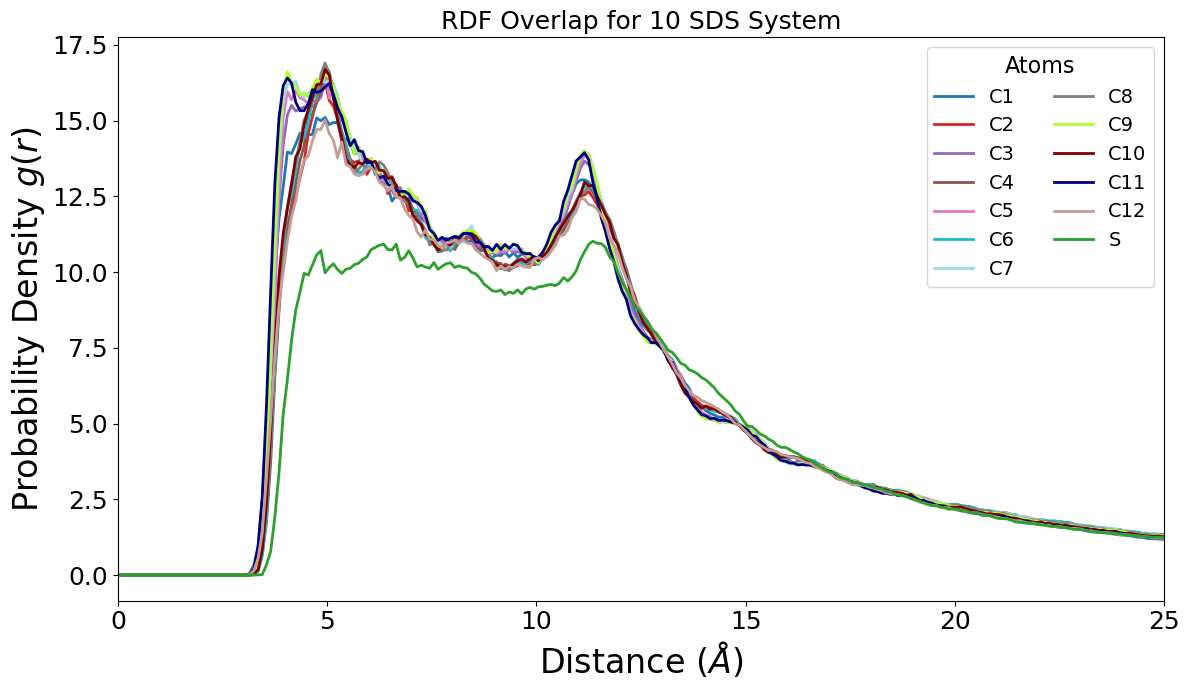

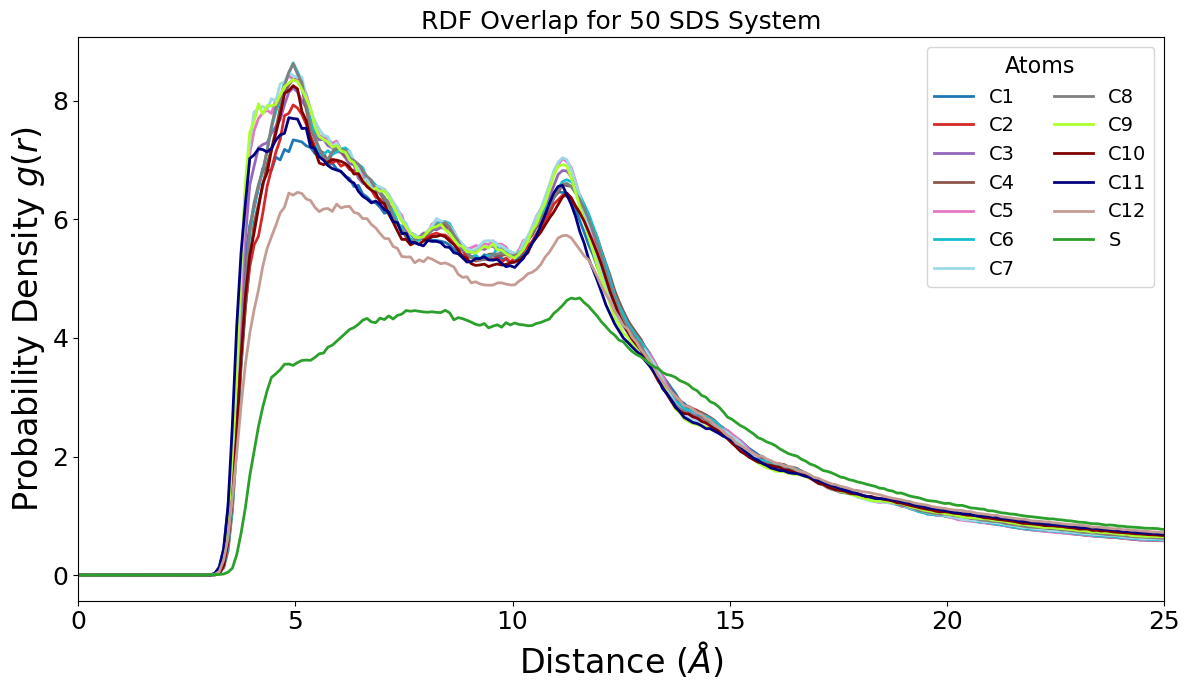

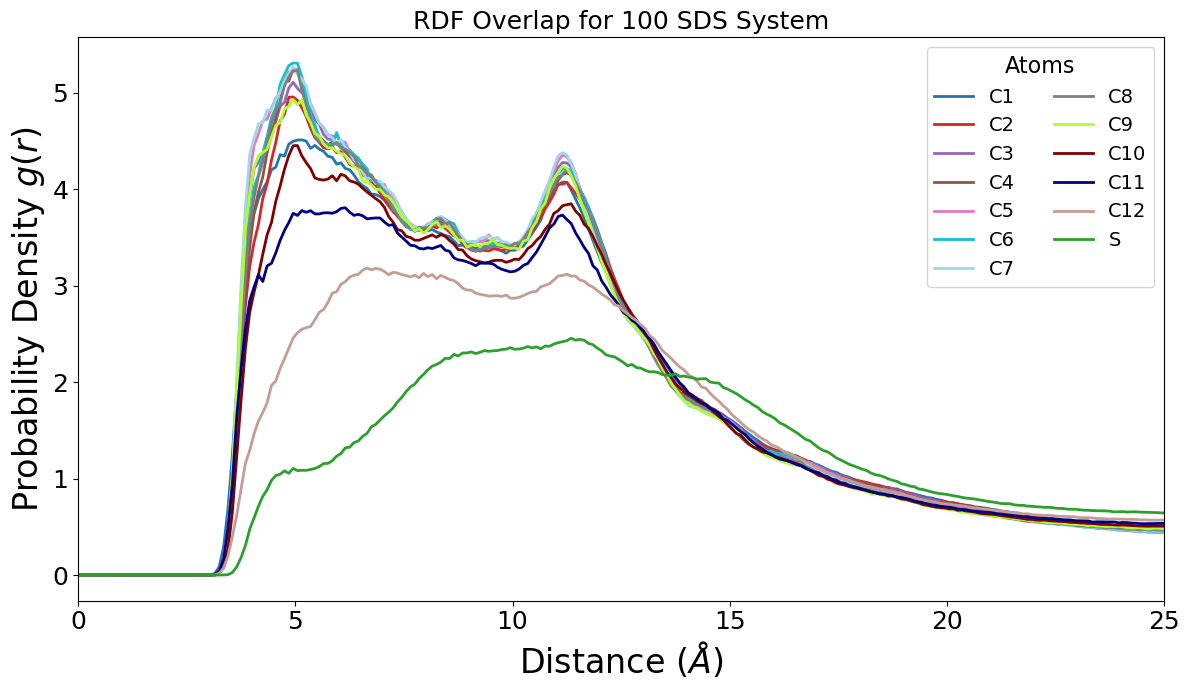

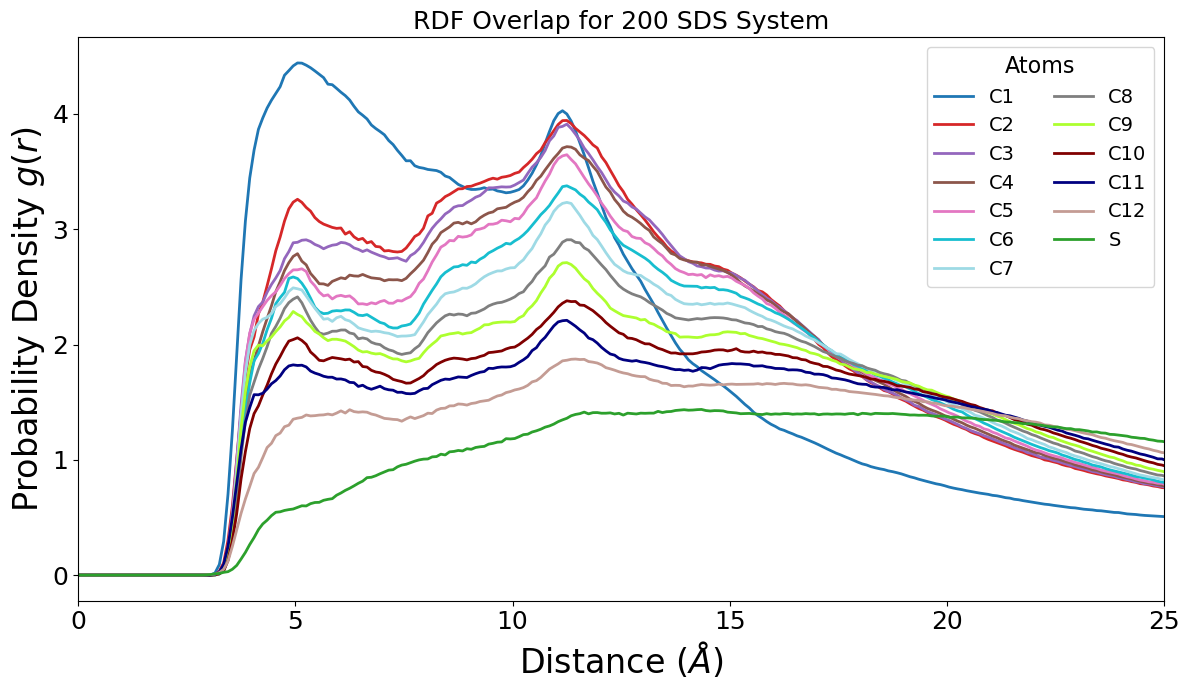

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 設定參數 ---
base_dir = "/home/jane/nano/add_ion/NPT/explicit/rdf_dat_1000/"  # 取 1000 frame
systems = [10, 50, 100, 200]

# 更新後的原子清單
atoms = [
    'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 
    'c9', 'c10', 'c11', 'c12', 'S'
]

# 更新後的標籤映射
atom_labels = {
    'c1': 'C1', 'c2': 'C2', 'c3': 'C3', 'c4': 'C4', 
    'c5': 'C5', 'c6': 'C6', 'c7': 'C7', 'c8': 'C8', 
    'c9': 'C9', 'c10': 'C10', 'c11': 'C11', 'c12': 'C12',
    'S': 'S'
}

# 更新後的顏色映射
atom_colors = {
    'c1': '#1f77b4', 'c2': '#d62728', 'c3': '#9467bd', 
    'c4': '#8c564b', 'c5': '#e377c2', 'c6': '#17becf', 
    'c7': '#9edae5', 'c8': '#7f7f7f', 'c9': '#adff2f', 
    'c10': '#800000', 'c11': '#000080', 'c12': '#c49c94',
    'S': '#2ca02c'
}

def get_path(count, atom):
    return os.path.join(base_dir, f"sds_{count}_{atom}.dat")

# --- 2. 核心繪圖邏輯 ---
def plot_system_rdfs():
    for count in systems:
        plt.figure(figsize=(12, 7)) # 稍微加寬一點
        data_plotted = False
        
        # 遍歷原子清單進行繪圖 (修正縮排)
        for atom in atoms:
            path = get_path(count, atom)
            
            if os.path.exists(path):
                try:
                    # 正常讀取檔案
                    x_plot, y_plot = np.loadtxt(path, unpack=True)
                    label = atom_labels[atom]
                    
                    # 繪圖
                    plt.plot(x_plot, y_plot, label=label, color=atom_colors[atom], linewidth=2)
                    data_plotted = True
                    
                except Exception as e:
                    print(f"讀取系統 {count} 之原子 {atom} 數據時發生錯誤: {e}")
                    continue
            else:
                # 檔案不存在則跳過
                continue

        if data_plotted:
            # 圖表格式設定
            plt.title(f"RDF Overlap for {count} SDS System", fontsize=18)
            plt.xlabel("Distance ($\AA$)", fontsize=24)
            plt.ylabel("Probability Density $g(r)$", fontsize=24)
            plt.xlim(0, 25) 
            
            # 優化圖例：使用 ncol=2 將 15 個原子分成兩列顯示，避免遮擋
            plt.legend(title="Atoms", fontsize=14, title_fontsize=16, loc='upper right', ncol=2)
            
            plt.tick_params(axis='both', which='major', labelsize=18)
            plt.tight_layout()
            
            # 存檔或顯示 (建議可以自動存檔)
            # plt.savefig(f"rdf_system_{count}.png", dpi=300)
            plt.show()
        else:
            print(f"系統 {count} 沒有找到任何可繪製的數據。")
            plt.close()

# --- 3. 執行 ---
if __name__ == "__main__":
    if not os.path.exists(base_dir):
        print(f"錯誤：目錄 {base_dir} 不存在，請檢查路徑。")
    else:
        print("正在生成各系統的原子 RDF 疊圖...")
        plot_system_rdfs()